# Puutyötunti projekti - koodin läpikäynti.

### kirjastot ja toistettavuus ->
* ensin tuodaan projektiin tarvittavat kirjastot. 
* randomin hallinta tehdään set_seed(42) funktiolla jotta tulokset pysyy toistettavina ajojen välillä.
* laitteistoon valitaan automaattisesti gpu (cuda:0) jos sellainen koneessa on, sekä oikea versio torchista asennettu. mikäli ei, otetaan suoritin eli cpu.

### datan lataaminen ja esikäsittely ->
* datasetti on .data nimisessä kansiossa ja jaettu kolmeen osaan train, val ja test.
* kuvat on muutettu vakiokokoon 224x224 mitä esiopetuksen mallit vaatii. = resize funktio
* dataan on sovellettu satunnaista vaakapeilausta = randomhorizontalflip. se ehkäisee overfittingiä ja parantaa mallin yleistyskykyä.
* data ladataan erissä = batch_size=32. nopeuttaa koulutusta ja vähentää muistin kulutusta (! potentiaalisesti, riippuu datasta ja mallista !)

### mallit ->
* mallin rakentaminen tehdään build_model funktiolla.
* mallit ovat tässä projektissa esikoulutettuja (imageNet data) = resnet18 + 50 ja efficientnet b0 (halusin yhden compound scaling method mallin)
* näillä malleilla resnet18 ja 50 mahdollistaa verkon syvyyden ja parametrimäärän vaikutusten vertailun saman arkkitehtuurin kesken ja efficientnetin (jätetty pois, syy koodin kommenteissa) mallin avulla voidaan verrata compound scalerin suorituskykyä verrattaen resnettiin.

### opetus + validointi ->
* mallit opetetaan 15 epookin ajan adam optimizerilla ja cross entropy loss funktiolla.
* jokasella epookilla malli ajaa train ja val vaiheen läpi.
* parhaan validaatiotarkkuuden saanut epookki ja sen painot tallennetaan muistiin (best_model_wts) kohdassa.

### testaus ja suorituskyvyn arviointi ->
* parhaat tallennetut mallit testataan vielä erillisellä testidatasetillä.
* lasketaan perustilastot: accuracy, precisioni, recall ja fi-pisteet.
* lasketaan myös top n tarkkuus ja sekaannusmatriisi.

### viimeiseksi visualisointi ->
* visualisoidaan sekaannusmatriisit ja tulostetaan taulukko jossa on kaikkien mallien suorituskykymittarit.




ajettava malli: resnet18
Epoch 01/15 | Val Acc: 0.4461 | Best Val Acc: 0.4461
Epoch 02/15 | Val Acc: 0.6784 | Best Val Acc: 0.6784
Epoch 03/15 | Val Acc: 0.7075 | Best Val Acc: 0.7075
Epoch 04/15 | Val Acc: 0.6598 | Best Val Acc: 0.7075
Epoch 05/15 | Val Acc: 0.7946 | Best Val Acc: 0.7946
Epoch 06/15 | Val Acc: 0.7365 | Best Val Acc: 0.7946
Epoch 07/15 | Val Acc: 0.4274 | Best Val Acc: 0.7946
Epoch 08/15 | Val Acc: 0.6037 | Best Val Acc: 0.7946
Epoch 09/15 | Val Acc: 0.7718 | Best Val Acc: 0.7946
Epoch 10/15 | Val Acc: 0.5311 | Best Val Acc: 0.7946
Epoch 11/15 | Val Acc: 0.7884 | Best Val Acc: 0.7946
Epoch 12/15 | Val Acc: 0.8174 | Best Val Acc: 0.8174
Epoch 13/15 | Val Acc: 0.7054 | Best Val Acc: 0.8174
Epoch 14/15 | Val Acc: 0.7365 | Best Val Acc: 0.8174
Epoch 15/15 | Val Acc: 0.8714 | Best Val Acc: 0.8714
Training complete in 46m 32s

ajettava malli: resnet50
Epoch 01/15 | Val Acc: 0.5830 | Best Val Acc: 0.5830
Epoch 02/15 | Val Acc: 0.8237 | Best Val Acc: 0.8237
Epoch 03/15 | Val 

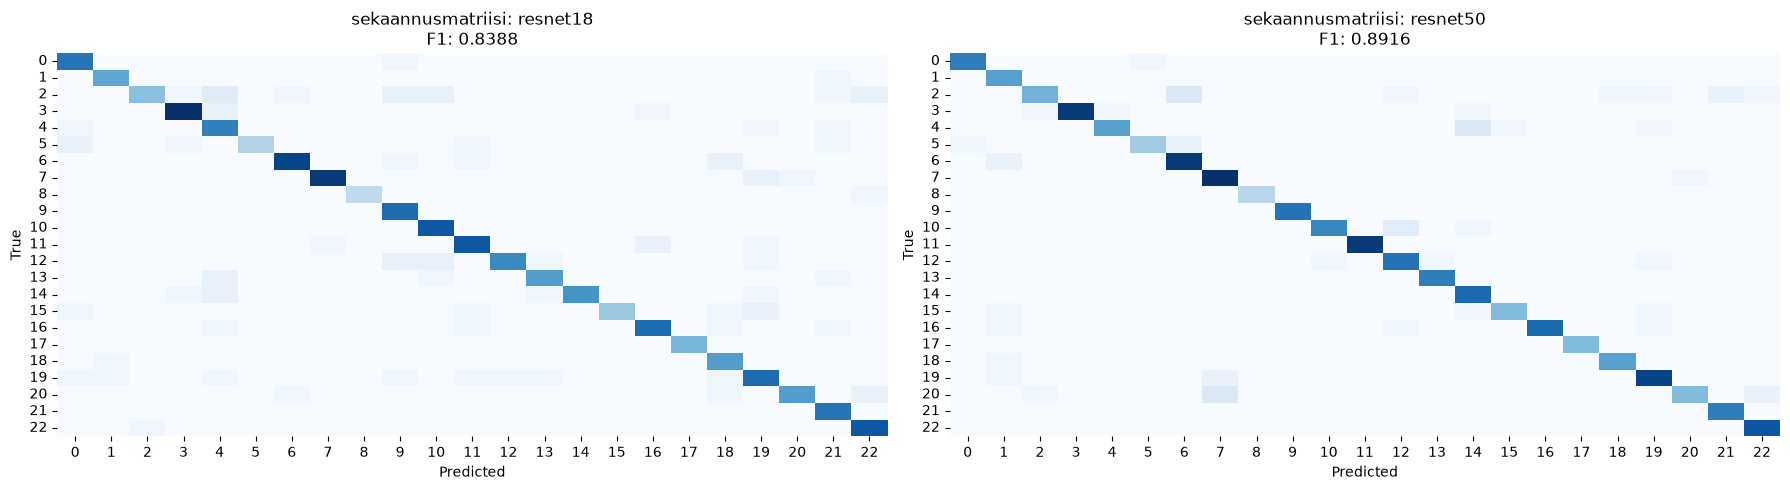

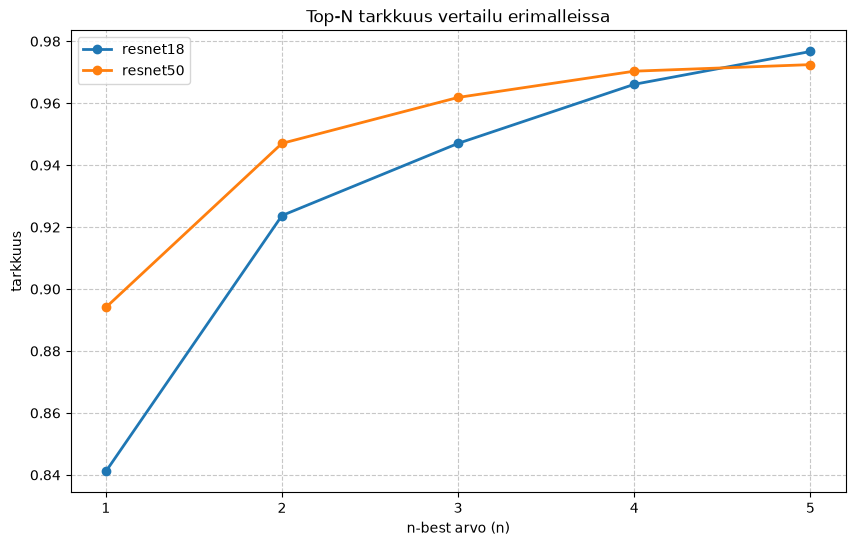


Top-N tarkkuusmatriisi:
-------------------------------------------------------
Model              | Top-1 | Top-2 | Top-3 | Top-4 | Top-5
-------------------------------------------------------
resnet18           | 0.8411 | 0.9237 | 0.9470 | 0.9661 | 0.9767
resnet50           | 0.8941 | 0.9470 | 0.9619 | 0.9703 | 0.9725
-------------------------------------------------------


In [1]:
import copy #-> tuodaan tarvittavat kirjastot
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 
# testeissä cuda = false eli väärä torchin versio. Mennään CPU:lla jotta vältetään yhteensopivuusongelmat huomioonottaen alun asennusohjeet.

DATA_DIR = './data'  # puut ovat data nimisessä kansiossa jossa on erikseen train val ja test kansiot.
BATCH_SIZE = 128
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
MAX_N = 5

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x == 'train'), num_workers=2)
    for x in ['train', 'val', 'test']
}

class_names = image_datasets['train'].classes
num_classes = len(class_names)


def build_model(architecture_name, num_classes): #--> mallin rakentaminen. weights.default = imageNetin painot.

    if architecture_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif architecture_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    #elif architecture_name == "efficientnet_b0":
    #    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT) -- JÄTETTY POIS KOSKA LIIAN RASKASTA JA TEHTÄVÄNANTO EI VAATINUT
    #    in_features = model.classifier[1].in_features
    #    model.classifier[1] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"vika arkkitehtuurissa!!!!: {architecture_name}")

    return model.to(device)


def train_and_validate(model, model_name, criterion, optimizer, num_epochs=15): #treenaus ja validaatioputki.
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print(f"\najettava malli: {model_name}")

    for epoch in range(num_epochs):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch + 1:02d}/{num_epochs:02d} | Val Acc: {epoch_acc:.4f} | Best Val Acc: {best_acc:.4f}")

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")

    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloader, max_n=5): # testievaluaatio ja top n tarkkuus.
    model.eval()
    all_labels = []
    all_preds_top1 = []

    top_n_correct = {n: 0 for n in range(1, max_n + 1)}
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)
            all_preds_top1.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            _, top_n_preds = outputs.topk(max_n, dim=1, largest=True, sorted=True)
            labels_expanded = labels.view(-1, 1).expand_as(top_n_preds)
            correct_matrix = top_n_preds.eq(labels_expanded)

            for n in range(1, max_n + 1):
                in_top_n = correct_matrix[:, :n].any(dim=1).sum().item()
                top_n_correct[n] += in_top_n

            total_samples += labels.size(0)

    acc = accuracy_score(all_labels, all_preds_top1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds_top1, average='weighted', zero_division=0
    )
    top_n_acc = {n: top_n_correct[n] / total_samples for n in range(1, max_n + 1)}

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'top_n_acc': top_n_acc,
        'y_true': np.array(all_labels),
        'y_pred': np.array(all_preds_top1)
    }

target_architectures = ["resnet18", "resnet50",] #"efficientnet_b0" # eksekkipipeline KTS YLLÄ EFFICIENTNET
trained_models = {}
evaluation_results = {}
criterion = nn.CrossEntropyLoss()

for arch in target_architectures:
    model = build_model(arch, num_classes)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    trained_model = train_and_validate(model, arch, criterion, optimizer, num_epochs=NUM_EPOCHS)
    trained_models[arch] = trained_model

    metrics = evaluate_model(trained_model, dataloaders['test'], max_n=MAX_N)
    evaluation_results[arch] = metrics


print("\n" + "=" * 75) # tulostetaan tablet
print(f"{'malliarkkitehtuuri':<20} | {'accuracy':<10} | {'precision':<10} | {'recall':<10} | {'F1_score':<10}")
print("=" * 75)
for arch, res in evaluation_results.items():
    print(f"{arch:<20} | {res['accuracy']:<10.4f} | {res['precision']:<10.4f} | {res['recall']:<10.4f} | {res['f1_score']:<10.4f}")
print("=" * 75)


fig, axes = plt.subplots(1, len(target_architectures), figsize=(18, 5)) #-> konfuusiomatriisit

for idx, arch in enumerate(target_architectures):
    cm = confusion_matrix(evaluation_results[arch]['y_true'], evaluation_results[arch]['y_pred'])
    ax = axes[idx] if len(target_architectures) > 1 else axes

    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"sekaannusmatriisi: {arch}\nF1: {evaluation_results[arch]['f1_score']:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6)) #arvioidaan n-best tarkkuus ja visualisaatio.

n_range = list(range(1, MAX_N + 1))
for arch in target_architectures:
    top_n_vals = [evaluation_results[arch]['top_n_acc'][n] for n in n_range]
    plt.plot(n_range, top_n_vals, marker='o', linewidth=2, label=arch)

plt.title("Top-N tarkkuus vertailu erimalleissa")
plt.xlabel("n-best arvo (n)")
plt.ylabel("tarkkuus")
plt.xticks(n_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print("\nTop-N tarkkuusmatriisi:")
print("-" * 55)
header = f"{'Model':<18} | " + " | ".join([f"Top-{n}" for n in n_range])
print(header)
print("-" * 55)
for arch in target_architectures:
    row = f"{arch:<18} | " + " | ".join([f"{evaluation_results[arch]['top_n_acc'][n]:.4f}" for n in n_range])
    print(row)
print("-" * 55)